In [1]:
import os

# Definindo a estrutura de pastas profissional
folders = [
    'data/raw',         # Dados brutos (sem mexer)
    'data/processed',   # Dados limpos prontos para o modelo
    'notebooks',        # Para seus estudos e EDA
    'src',              # Scripts de processamento e treinamento
    'models',           # Onde salvaremos o "cérebro" da IA
    'api'               # Código da API Flask
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Estrutura de pastas de Produção criada com sucesso!")

✅ Estrutura de pastas de Produção criada com sucesso!


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def generate_fraud_data(n_samples=5000):
    np.random.seed(42)

    # Criando IDs e Datas
    start_date = datetime(2026, 1, 1)
    dates = [start_date + timedelta(minutes=np.random.randint(0, 525600)) for _ in range(n_samples)]

    data = pd.DataFrame({
        'transaction_id': range(1, n_samples + 1),
        'timestamp': dates,
        'valor': np.random.exponential(scale=100, size=n_samples), # Maioria dos valores é baixo
        'distancia_casa': np.random.normal(loc=5, scale=10, size=n_samples).clip(0),
        'tentativas_senha': np.random.poisson(lam=1, size=n_samples).clip(1, 5),
        'is_fraud': 0
    })

    # Lógica de Fraude (Probabilística):
    # 1. Transações de madrugada (0h às 5h) têm mais chance
    data['hour'] = data['timestamp'].dt.hour
    madrugada = (data['hour'] >= 0) & (data['hour'] <= 5)

    # 2. Valores muito altos ou distâncias muito grandes
    valor_alto = data['valor'] > 800
    distancia_longa = data['distancia_casa'] > 80

    # Aplicando a "Sujeira" (Fraude real)
    fraud_mask = (madrugada & valor_alto) | (distancia_longa & (data['tentativas_senha'] > 2))
    data.loc[fraud_mask, 'is_fraud'] = np.random.choice([0, 1], size=fraud_mask.sum(), p=[0.2, 0.8])

    return data

df = generate_fraud_data()
df.to_csv('data/raw/transactions.csv', index=False)
print(f"✅ Dataset gerado: {df.shape[0]} transações. Fraudes detectadas: {df.is_fraud.sum()}")

✅ Dataset gerado: 5000 transações. Fraudes detectadas: 2


/tmp/ipykernel_538/1231154004.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='valor', data=df, palette='viridis')


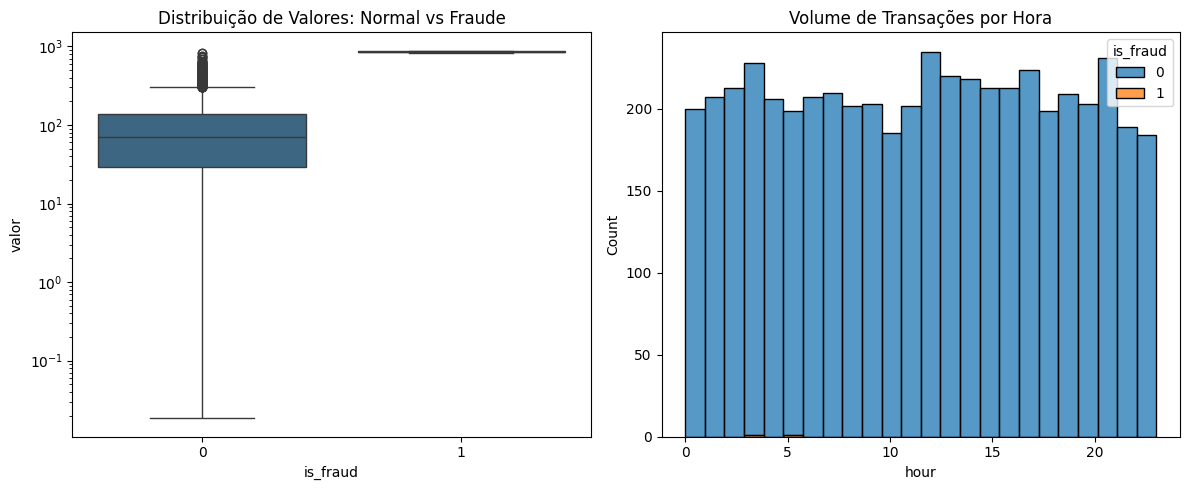

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribuição de Valores
plt.subplot(1, 2, 1)
sns.boxplot(x='is_fraud', y='valor', data=df, palette='viridis')
plt.title('Distribuição de Valores: Normal vs Fraude')
plt.yscale('log') # Escala logarítmica para ver melhor os outliers

# Gráfico 2: Horário da Transação
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='hour', hue='is_fraud', multiple='stack', bins=24)
plt.title('Volume de Transações por Hora')

plt.tight_layout()
plt.show()

In [4]:
def preprocess_data(df_input):
    df_temp = df_input.copy()

    # Feature Engineering
    df_temp['is_night'] = df_temp['hour'].apply(lambda x: 1 if x <= 5 or x >= 23 else 0)
    df_temp['valor_por_tentativa'] = df_temp['valor'] / df_temp['tentativas_senha']

    # Limpeza: Remover colunas que não ajudam na predição (IDs e Timestamps brutos)
    features = ['valor', 'distancia_casa', 'tentativas_senha', 'hour', 'is_night', 'valor_por_tentativa']
    X = df_temp[features]
    y = df_temp['is_fraud']

    return X, y

X, y = preprocess_data(df)
X.to_csv('data/processed/features.csv', index=False)
print("✅ Features preparadas para o modelo.")

✅ Features preparadas para o modelo.


--- RELATÓRIO DE PERFORMANCE ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      4998
           1       0.01      1.00      0.02         2

    accuracy                           0.95      5000
   macro avg       0.50      0.98      0.50      5000
weighted avg       1.00      0.95      0.97      5000



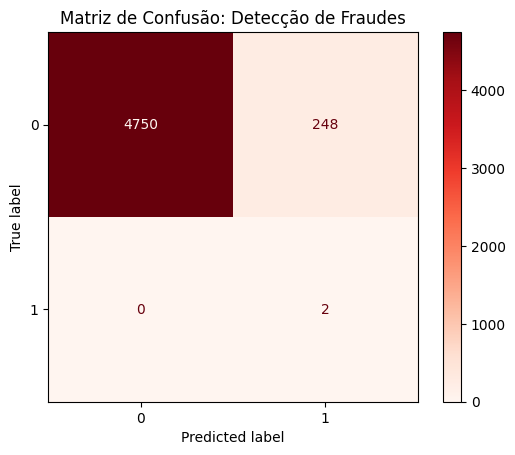

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Em Isolation Forest, ele retorna -1 para anomalia e 1 para normal.
# Precisamos ajustar para o nosso y (0 e 1).
model = IsolationForest(contamination=0.05, random_state=42) # contamination é a % esperada de fraude
model.fit(X)

# Predição
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred] # Convertendo para nosso padrão

# Avaliação
print("--- RELATÓRIO DE PERFORMANCE ---")
print(classification_report(y, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Reds')
plt.title('Matriz de Confusão: Detecção de Fraudes')
plt.show()

In [6]:
import joblib

# Salvando o modelo e a lista de colunas para garantir que a API use a mesma ordem
joblib.dump(model, 'models/fraud_detector_model.pkl')
joblib.dump(list(X.columns), 'models/features_list.pkl')
print("✅ Modelo serializado com sucesso em /models")

✅ Modelo serializado com sucesso em /models


In [7]:
# Criando o arquivo de script da API dentro da pasta /api
api_code = """
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Carregando o modelo e a lista de features que salvamos no Passo 8
model = joblib.load('models/fraud_detector_model.pkl')
features_list = joblib.load('models/features_list.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        df_input = pd.DataFrame([data])

        # O Isolation Forest retorna -1 para anomalia (fraude) e 1 para normal
        prediction = model.predict(df_input[features_list])

        resultado = "ALERTA: Fraude Detectada" if prediction[0] == -1 else "Transação Normal"

        return jsonify({
            'status': resultado,
            'prediction_code': int(prediction[0]),
            'mensagem': 'Análise concluída com sucesso'
        })
    except Exception as e:
        return jsonify({'error': str(e)})

if __name__ == '__main__':
    app.run(port=5000)
"""

with open('api/app.py', 'w') as f:
    f.write(api_code)

print("✅ Arquivo api/app.py criado com sucesso!")

✅ Arquivo api/app.py criado com sucesso!


In [8]:
requirements = """
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
flask
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ Arquivo requirements.txt criado!")

✅ Arquivo requirements.txt criado!
